## Start modelering van voorspellingsmodel

Na onze EDA ga we ons model trainen. Dit gaan we doen in de volgende stappen. Eerst halen we onze data op van het [bestand](../../csv/new_train_data/train_CarBreakDown.csv) dat we via de EDA hebben opgeleverd. Vervolgens wordt de data in afhankelijke en onafhankelijke variablen gesplits en vervolgens in train en evaluatie data. Na een deze velden (als ze categorisch zijn) nog te encoderen wordt het model getrained. Als laatste volgt er nog extra visualisatie zoals een confusion matrix en wordt het antwoord geexporteerd naar [test_answer.csv](../../csv/test/test_answer.csv).

### Installaties

Voor er begonnen kan worden moeten deze libraries nog geïnstalleerd worden 

In [ ]:
!pip install category_encoders
!pip install XGBoost
!pip install SMOTE

### Import data

In [ ]:
import pandas as pd
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import metrics
import seaborn as sns


df = pd.read_csv("../../csv/new_train_data/train_CarBreakDown.csv")

# Split method

# df_safe = df[df['breakdown_next_30_days'] == 0]
# df_breakdown = df[df['breakdown_next_30_days'] == 1]

### Splits data in x en y en in train en evaluatie data

Bij het splitsen van de data gebruiken we alle velden als onafhankelijk variabelen(X). Bij het experimenteren van velden om weg te laten zaggen we niet een merkbaar verschil in onze resultaten. Voor een voorbeeld zie Extra **"Zonder categorische velden"**. Voor de data in train en validatie data te splitsen wordt de **train_test_split** methode gebruikt met **20%** validatie data. Onze dataset is redelijk beperkt dus 20% is een goed maximum om te nemen.

In [72]:
used_features =['vehicle_brand','vehicle_age_years', 'mileage_km','engine_hours','last_service_km_ago','oil_quality_pct','avg_trip_length_km','weather_exposure','fuel_type','cleanliness_score','driver_satisfaction_score','tyre_type']

x = df[used_features]
y = df[['breakdown_next_30_days']]

# Split method

# x_safe = df_safe[used_features]
# x_breakdown = df_breakdown[used_features]
# y_safe = df_safe[['breakdown_next_30_days']]
# y_breakdown = df_breakdown[['breakdown_next_30_days']]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)


#### Onafhankelijke variabelen (X)

In [ ]:
x

#### Afhankelijke variabel (y)

In [ ]:
y

,breakdown_next_30_days
0,0
1,0
2,0
3,0
4,0
...,...
739,0
740,0
741,1
742,0


### Encoding van categorische velden

Sommige velden in de data set zijn categorisch en moeten eerst geconverteerd worden naar numerieke waarde. Via the OrdinalEncoder worden de velden `'vehicle_brand','weather_exposure','fuel_type','tyre_type'` geconverteerd. Hier komt ook onze eerste grote afwijking van het verwerken van de data. Via SMOTE worden er extra synthetische records gemaakt. Dit wordt gebruikt omdat de dataset een groot aantal auto's heeft die niet kapot gaan waardoor een model die hier op trained meer waarschijnlijk niet kapot gokt dan dat het kapot gaat gokken. Voor meer uitleg rond SMOTE zie Extra **"SMOTE"**.

In [75]:
category_encoder = ce.OrdinalEncoder(cols = ['vehicle_brand','weather_exposure','fuel_type','tyre_type'])

x_encoded = category_encoder.fit_transform(x_train)

# Split method

# x_safe_encoded = category_encoder.fit_transform(x_safe)
# x_breakdown_encoded = category_encoder.transform(x_breakdown)

x_test_encoded = category_encoder.transform(x_test)
x_encoded

from imblearn.over_sampling import SMOTE

smote = SMOTE()
x_encoded, y_train = smote.fit_resample(x_encoded, y_train)

### Train model via Random forest/XGBoost

Na het verdelen van alle data wordt een model hier op getrained. Bij onze gebruiken we twee manieren, via een **Random forest** of via **XGBoost**. Voor Random forest wordt de entropy formule gebruikt en bv. niet gini voor de chaos in de dataset te meten. Het verschil hier in is niet opmerkbaar. De rest van de parameters`n_estimators, max_samples,max_depth,class_weight` zorgen ook voor meer specificatie tijdens het trainingsprocess. De meest opvallende is class_weight. Als deze op balanced staat betekend dat het alle afhankelijke variabelen zal doorwegen tijdens splitsingen afhankelijk van hun frequentie. Voor een bredere uitleg rond XGBoost zie Extra **"XGBoost"**. 

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Split method

# end_df = pd.DataFrame([])
# end_df = pd.concat([end_df, x_breakdown_encoded])
# end_df = pd.concat([end_df, x_safe_encoded.sample(n=x_breakdown_encoded.shape[0])])

clf = RandomForestClassifier(criterion='entropy',n_estimators=100, max_samples = 100, max_depth=6, class_weight="balanced")
clf = clf.fit(x_encoded, y_train.values.ravel()) # values.ravel() because a warning appears about using a 1d array so we need to flatten it.




from xgboost import XGBClassifier
# create model
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
  
)

# train 
clf.fit(x_encoded, y_train)
model.fit(x_encoded, y_train)

# Split method

# use end_df and .sample(n=x_breakdown_encoded.shape[0]*2) instead for the fit



# proba = model.predict_proba(x_test_encoded)[:,0]

# pred = (proba > 0.95).astype(int)
# pred

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

#### Voorspelling output

In [77]:
# Voorspel (Kies model door clf (voor RandomForest) of model (voor XGBoost) te gebruiken)
clf_prediction = model.predict(x_test_encoded)
print(clf_prediction)

[0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0
 0 1 1 1 1 1 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0
 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 0 0 1 1 0
 0 1 0 0 0 0 1 0 1 1 0 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 1 1 1 1 0 0
 0]


#### Accuracy weergave

In [78]:
print(f"Accuracy: {metrics.accuracy_score(y_test, clf_prediction)}")

Accuracy: 0.6912751677852349


#### Confusion matrix

Hieronder is een confusion matrix te zien. De X-as toont de voorspelling die het model heeft gemaakt en de y-ass wat het in werkelijkheid zou moeten zijn. In de matrix kun je zien dat we False positives( links onder) zo miniem mogelijk willen houden. Dit is voor ons belangrijk omdat een fout in het gokken dat het niet kappot gaat erger is dan zeggen dat het wel kapot gaat en dat dit niet zo is. Vooral het toepassen van SMOTE hielp hier om minder false positives te hebben. Dit koste het model wel accuraatheid doordat het niet meer enkel niet kapot gokte waardoor er meer false negatives waren wat voor ons ok is. 

In [ ]:
sns.heatmap(confusion_matrix(y_test, clf_prediction),
            annot=True, fmt="d", cmap="PuBuGn",
            
            xticklabels=["niet kapot", "kapot"],
            yticklabels=["niet kapot", "kapot"])

Mean F1: 0.7987973572020609


Nog een visualisatie die jammer genoeg enkel voor XGBoost is, is de importance plot. Het toont een bar chart met alle features, gemeten met hoe belangrijk ze zijn voor de voorspelling van het model. Uit deze grafiek kwam ook het idee om de categorische kollomen niet meer mee te nemen wat uiteindelijk naar niets leide. Zie Extra **"Zonder categorische velden"**.

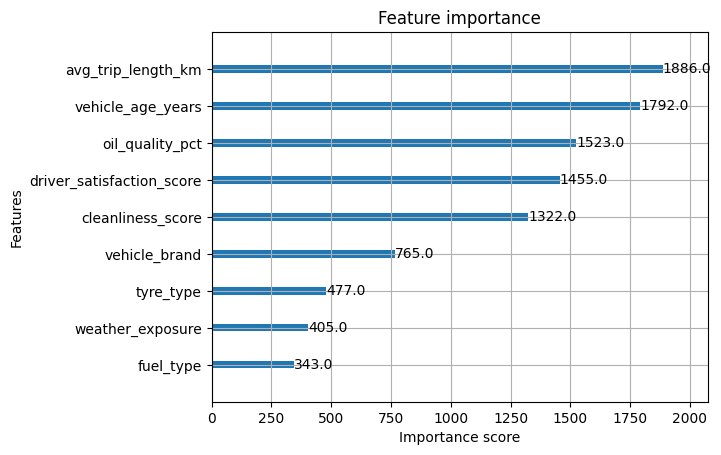

In [81]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

# gebruik enkel bij XGBoost model
# plot_importance(model)
# plt.show()

## Voorspelling maken op echte data

Hier wordt uiteindelijk te echte data geimporteerd om een voorspelling op te maken. Het eind resultaat wordt naar [test_answer.csv](../../csv/test/test_answer.csv) gestuurd om dan verwerkt worden naar het eind resultaat in [start_structure.ipynb](../start_structure.ipynb)

In [ ]:
kaggle_submit_data = pd.read_csv("../../csv/test/test_CarBreakDown.csv")
kaggle_submit_data_encoded = category_encoder.transform(kaggle_submit_data[used_features])
kaggle_submit_predictions = model.predict(kaggle_submit_data_encoded)
with open("../../csv/test/test_answer.csv", "w") as f:
    f.write("breakdown_next_30_days\n")
    for prediction in kaggle_submit_predictions:
        f.write(f"{prediction}\n")
kaggle_submit_predictions

## Extra

De dataset had 1 opvallend probleem. Voor dit op te lossen hebben we technieken gebruikt die hieronder beschreven worden.

### Splitsen van de data in breakdown en niet breakdown data

Bij deze techniek splitte we de data op in twee data frames (Zie # split method). 1 dataframe was met auto's die kapot gingen en de andere die niet kapot gingen.Vervolgens namen we 100 van elke dataframe en combineerde deze voor onze eind dataset om op te trainen. Uiteindelijk leek het niet veel effect te hebben op de resultaten. Ook probeerde we om duplicate rijen van de de breakdown dataframe te nemen om een te kort aan data te voorkomen maar leek ook niet veel effect te hebben.

### Voorspellings zekerheidsgrens aanpassen
proba = clf.predict_proba(x_test_encoded)[:,0]

pred = (proba > 0.81).astype(int)

pred

De boven staande code zorgt ervoor dat het model boven een bepaalde zekerheid moet zijn om een voorspelling te maken (in dit geval 81% zekerheid over niet breakdown). Dit had een positief effect op het aantal false positves maar zorgde ook dat onze accuraatheid heel laag werd en het niet waard was om te gebruiken.

### SMOTE

SMOTE staat voor Synthetic Minority Over-Sampling Technique en is een techniek om extra records van minderheids klasse aan te maken zoals in onze dataset is. Hier is een kleine samen vatting van wat SMOTE doet volgens de volgende [Bron](https://www.geeksforgeeks.org/machine-learning/smote-for-imbalanced-classification-with-python/). 

Eerst bepaalt het welke klasse geonder representeerd zijn. Vervolgens worden k aantal records gekozen die het dicht bij de huidige gekozen sample liggen op basis van hun features, met k als default 5. Hierna wordt 1 buur gekozen wordt een nieuw record gemaakt met 1 element verschil die tussen de waarde lag van de originele sample en de buur. Dit herhaalt zich tot dat de klasse een gelijkend aantal records hebben.

Deze techniek hielp het meeste met de false positives. Dit had wel het nadeel dat het de accuracy velaagde want false negatives stegen maar het was beter dan de techniek er boven.

### XGBoost

XGBoost of Extreme Gradient Boosting is een boosting algorithme. Dit betekent dat het iteratief werkt. Het gebruikt meerdere descision trees die van elkaar hebben geleerd om steeds te verbeteren om uit eindelijk 1 eind model te hebben die goede voorspellingen kan maken. Dit is in tegenstelling tot the random forest die ook meerdere decision trees maakt met verschillende data maar die niet elkaar beïnvloeden.
Uit het testen van dit algorithme konden we zien dat het meer accuraten resultaten kon bekomen dan de Random forest. Het had wel meer false positives dan de random forest dus de keuze is afhankelijk van wat het belangrijkste is voor de persoon die het algorithme gebruikt.

### Zonder categorische velden

Uit de importance plot konden we afleiden dat de velden `Oil_quality_pct, vehicle_brand, fuel_type, tyre_type en weather_exposure` minder belang hadden in het keuze process. Hierop volgend deden we een test wat er zou gebeuren als we deze kolomen weg hielden uit het trainen van het model als onafhankelijke variabel. Uit het testen bleek dat het niet een merkbaar effect had op de resultaten dus werd terug alle features gebruikt voor de training.